In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
healthy_data = pd.read_csv("../data/processed/02_healthy_data.csv")


Look at how many different studies are involved here:

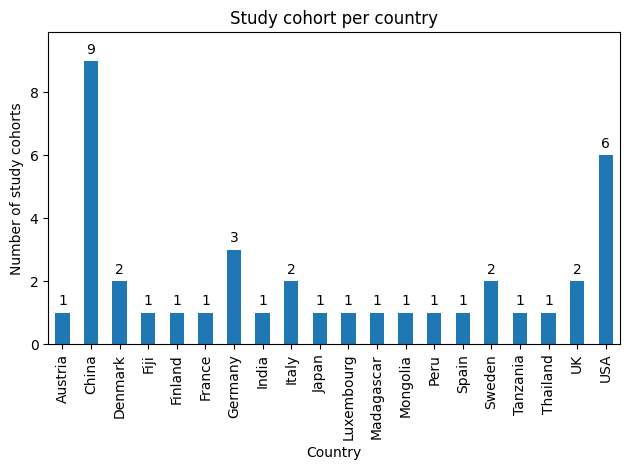

In [39]:
count_study = healthy_data.groupby("Geography")["BioProject"].nunique()


# 1. Create the plot and capture the 'axes' object (ax)
ax = count_study.plot(kind="bar")

# 2. Add the labels using bar_label
# ax.containers[0] identifies the bars in the plot
ax.bar_label(ax.containers[0], padding=3)

# 3. Rest of your formatting
plt.ylabel("Number of study cohorts")
plt.xlabel("Country")
plt.title("Study cohort per country")

# Adjust y-axis limit slightly so the labels don't get cut off at the top
plt.ylim(0, count_study.max() + (count_study.max() * 0.1))

plt.tight_layout()
plt.show()

There are overall 35 different study cohorts

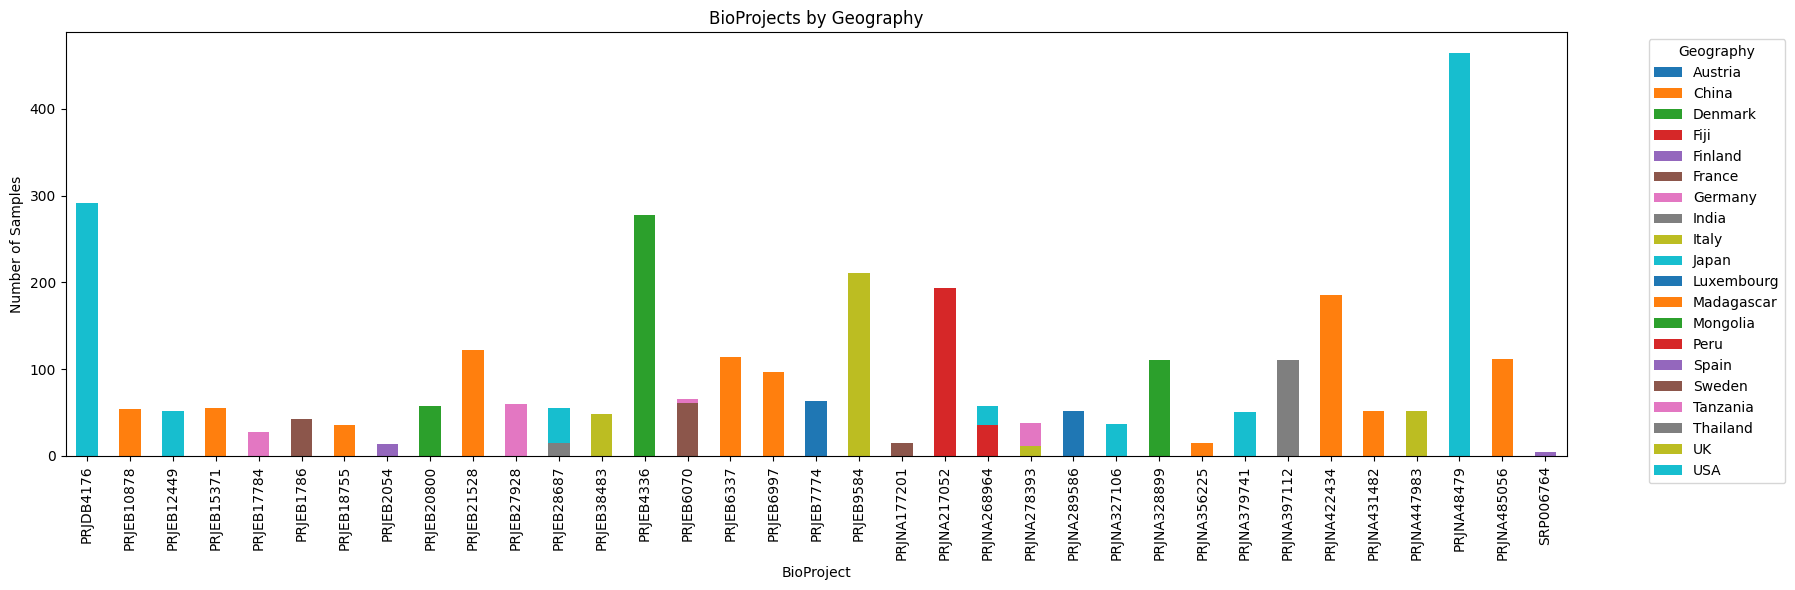

In [30]:
pivot = healthy_data.groupby(["BioProject", "Geography"]).size().unstack(fill_value=0)

pivot.plot(kind="bar", stacked=True, figsize=(18, 6))
plt.ylabel("Number of Samples")
plt.title("BioProjects by Geography")
plt.xticks(rotation=90)
plt.legend(title="Geography", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
missing_values = healthy_data.iloc[:,:10].isna().sum()

missing_values

sample.ID         0
BioProject        0
Age             604
Gender          399
BMI             833
Geography         0
Sequencer         0
MgsRichness       0
GeneRichness      0
enteroType        0
dtype: int64

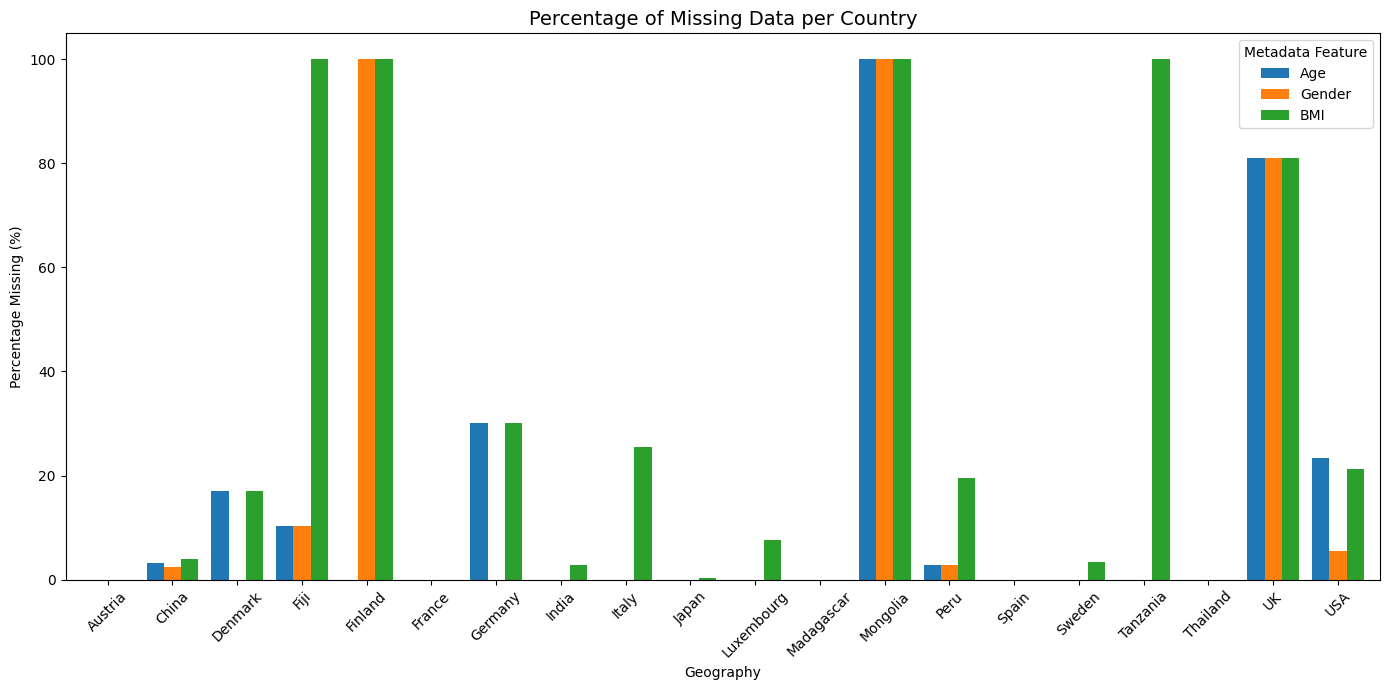

In [35]:
# Calculate percentage of missing values (isna().mean() * 100)
missing_pct = healthy_data.groupby("Geography")[["Age", "Gender", "BMI"]].apply(lambda x: x.isna().mean() * 100)

missing_pct.plot(kind="bar", figsize=(14, 7), width=0.8)
plt.title("Percentage of Missing Data per Country", fontsize=14)
plt.ylabel("Percentage Missing (%)")
plt.ylim(0, 105) # Keeps the scale consistent
plt.xticks(rotation=45)
plt.legend(title="Metadata Feature")
plt.tight_layout()
plt.show()